In [ ]:
import nbtlib
from nbtlib import serialize_tag
import numpy as np
from pathlib import Path
import json
import shutil
import logging
import traceback
import uvarint

logging.basicConfig(level=logging.DEBUG,
                    filename="change_data.log",
                    filemode='w',
                    encoding='utf8',
                    format="%(asctime)s - %(levelname)s - %(message)s",
                    force=True)
data_dir = Path("./data")
universal_palette = {}




for folder in data_dir.iterdir():
    try:
        logging.info(f"READING FOLDER {folder}")
        schem_file = folder / "map.schem"
        logging.info(f"READING FILE {schem_file}")
        
        
        schem_data = nbtlib.load(schem_file)
        if "Schematic" in schem_data:
            logging.info("THIS FILE HAS SCHEMATIC KEY INSIDE")
            palette = schem_data["Schematic"]["Blocks"]["Palette"]
            
        else:
            logging.info("THIS FILE DOES NOT HAVE SCHEMATIC KEY, SKIPPING IT")
            shutil.rmtree(folder)
            continue
        
        logging.info(f"CURRENT LENGTH OF THE UNIVERSAL PALETTE IS {len(universal_palette)}")
        logging.info(f"LENGTH OF THE CURRENT LOCAL PALETTE FILE IS {len(palette)}")
        for block_name in palette.keys():
            if block_name not in universal_palette:
                universal_palette[block_name] = len(universal_palette)
        logging.info(f"AFTER CHANGING THE LENGHT OF THE UNIVERSAL PALETTE IS {len(universal_palette)}")
    except Exception as error:
        logging.exception("Неожиданная ошибка")
        print("Тип ошибки:", type(error).__name__)
        print("Сообщение:", error)
        traceback.print_exc()
        continue
with open("legacy.json",'w',encoding='utf8') as file:
    json.dump(universal_palette, file, ensure_ascii=False,indent=2)


for folder in data_dir.iterdir():
    schem_file = folder / "map.schem"   
    schem_data = nbtlib.load(schem_file) 
    data = schem_data["Schematic"]["Blocks"]["Data"]
    palette = schem_data["Schematic"]["Blocks"]["Palette"]
    # X =  schem_data["Schematic"]['Width'] 
    # Y = schem_data["Schematic"]['Height'] 
    # Z = schem_data["Schematic"]['Length']
    # print(f"TOTAL BLOCKS:{X*Y*Z}")
    palette_reverse = {int(local_id):block_name for block_name, local_id in palette.items()}
    i = 0
    data_new = []
    raw = bytes(x & 0xFF for x in data)
    while i < len(raw):
        value,size = uvarint.decode(raw[i:])
        data_new.append(value)
        i += size
  
    data_universal = []
    for local_id in data_new:
        block_name = palette_reverse[local_id]
        universal_id = universal_palette[block_name]
        data_universal.append(universal_id)
    


#осталось превратить data_universal в формат varint снова.


        




TOTAL BLOCKS:233919
TOTAL LENGTH OF DATA BLOCKS FILE 233919


In [5]:
from pathlib import Path 
import nbtlib
from collections import Counter
data_dir = Path("./data")
# print(data_dir)
combo_counts = Counter()
for folder in data_dir.iterdir():
    schem_file = folder / "map.schem"
    try:
        print(f"Начал папку {folder}")
        schem_data = nbtlib.load(schem_file)
        Version = schem_data["Schematic"]["Version"]
        DataVersion = schem_data["Schematic"]["DataVersion"]
        combo_counts[(Version,DataVersion)] += 1
    except Exception as e:
        print(f"Пропустил папку :{folder} - {e}")
        continue
print(combo_counts)

Начал папку data\map100_19
Начал папку data\map100_20
Начал папку data\map100_7
Начал папку data\map101_14
Начал папку data\map101_15
Начал папку data\map101_16
Начал папку data\map101_17
Начал папку data\map101_2
Начал папку data\map102_1
Начал папку data\map102_11
Начал папку data\map102_24
Начал папку data\map103_12
Начал папку data\map103_16
Начал папку data\map104_13
Начал папку data\map104_18
Начал папку data\map104_2
Начал папку data\map104_25
Начал папку data\map105_16
Начал папку data\map105_21
Начал папку data\map106_15
Начал папку data\map106_17
Начал папку data\map106_18
Начал папку data\map106_5
Начал папку data\map107_11
Начал папку data\map107_23
Начал папку data\map107_7
Начал папку data\map107_8
Начал папку data\map108_15
Начал папку data\map108_16
Начал папку data\map108_17
Начал папку data\map108_18
Начал папку data\map108_19
Начал папку data\map108_20
Начал папку data\map108_25
Начал папку data\map108_3
Начал папку data\map108_9
Начал папку data\map109_13
Начал папк

In [26]:
import mcschematic

new_schematic = mcschematic.MCSchematic()

# full имеет порядок: Y, Z, X
for y in range(full.shape[0]):
    for z in range(full.shape[1]):
        for x in range(full.shape[2]):

            block_name = str(full[y, z, x])

            if block_name == "unknown":
                raise ValueError(
                    f"Неизвестный блок в координатах: y={y}, z={z}, x={x}"
                )

            # mcschematic принимает координаты в порядке X, Y, Z
            new_schematic.setBlock(
                (x, y, z),
                block_name
            )

new_schematic.save(
    "./generated",
    "colosseum_from_full",
    mcschematic.Version.JE_1_18_2
)

print("Файл создан")

TypeError: File.__init__() got an unexpected keyword argument 'root_name'

In [51]:
import json
with open("legacy.json",'r',encoding='utf8') as file:
    palette = json.load(file)

In [58]:
print(palette.keys())
print(palette["items"])
print(palette["blocks"])

dict_keys(['blocks', 'items'])
{'0:0': 'minecraft:air', '1:0': 'minecraft:stone', '1:1': 'minecraft:granite', '1:2': 'minecraft:polished_granite', '1:3': 'minecraft:diorite', '1:4': 'minecraft:polished_diorite', '1:5': 'minecraft:andesite', '1:6': 'minecraft:polished_andesite', '2:0': 'minecraft:grass_block', '3:0': 'minecraft:dirt', '3:1': 'minecraft:coarse_dirt', '3:2': 'minecraft:podzol', '4:0': 'minecraft:cobblestone', '5:0': 'minecraft:oak_planks', '5:1': 'minecraft:spruce_planks', '5:2': 'minecraft:birch_planks', '5:3': 'minecraft:jungle_planks', '5:4': 'minecraft:acacia_planks', '5:5': 'minecraft:dark_oak_planks', '6:0': 'minecraft:oak_sapling', '6:1': 'minecraft:spruce_sapling', '6:2': 'minecraft:birch_sapling', '6:3': 'minecraft:jungle_sapling', '6:4': 'minecraft:acacia_sapling', '6:5': 'minecraft:dark_oak_sapling', '7:0': 'minecraft:bedrock', '12:0': 'minecraft:sand', '12:1': 'minecraft:red_sand', '13:0': 'minecraft:gravel', '14:0': 'minecraft:gold_ore', '15:0': 'minecraft:ir

In [5]:
print(blocks.shape)

(192, 340, 340)


In [6]:
palette = dict_data["Palette"]
# print(palette)
print(palette.items())
# for i,j in palette.items():
#     print(i,j)

air_id = [block_id for block_name,block_id in palette.items() if "air" in block_name]
print(air_id)




dict_items([('minecraft:air', Int(0)), ('minecraft:black_concrete', Int(1)), ('minecraft:sculk', Int(2)), ('minecraft:gray_concrete', Int(3)), ('minecraft:black_wool', Int(4)), ('minecraft:dark_prismarine', Int(5)), ('minecraft:warped_planks', Int(6)), ('minecraft:andesite', Int(7)), ('minecraft:polished_blackstone', Int(8)), ('minecraft:smooth_basalt', Int(9)), ('minecraft:gray_wool', Int(10)), ('minecraft:warped_stem', Int(11)), ('minecraft:polished_blackstone_bricks', Int(12)), ('minecraft:blackstone', Int(13)), ('minecraft:cracked_polished_blackstone_bricks', Int(14)), ('minecraft:cyan_concrete', Int(15)), ('minecraft:light_blue_wool', Int(16)), ('minecraft:light_blue_terracotta', Int(17)), ('minecraft:cyan_wool', Int(18)), ('minecraft:coal_block', Int(19)), ('minecraft:cyan_terracotta', Int(20)), ('minecraft:light_blue_concrete', Int(21)), ('minecraft:prismarine', Int(22)), ('minecraft:sea_lantern', Int(23)), ('minecraft:prismarine_bricks', Int(24)), ('minecraft:basalt', Int(25)),

In [11]:
arr = blocks != 0 
# print(type(solid))

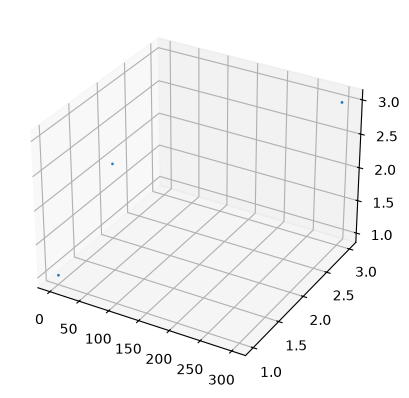

In [26]:
import numpy as np
import matplotlib.pyplot as plt

x, y, z = np.where(arr)

step = 10  # показываем каждую двадцатую точку

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter([1,2,300],[1,2,3],[1,2,3], s=1)

plt.show()